#### Imports

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math 
import pandas as pd

#### DoG Segmentation Function

##### General segmentation

In [18]:
def extract_chocolate_segments(
    image_path, 
    std_thresh=5.0, 
    iou_thresh=0.7,
    area_thresholds=[(110000, 400000), (100000, 300000), (40000, 200000)],
    final_max_area=400000
):
    def difference_of_Gaussians(img, k1, s1, k2, s2):
        b1 = cv2.GaussianBlur(img, (k1, k1), s1)
        b2 = cv2.GaussianBlur(img, (k2, k2), s2)
        return b1 - b2

    def detect_chocolates(thresholded_img, area_min=110000, area_max=350000, excluded_mask=None):
        if excluded_mask is not None:
            th = thresholded_img.copy()
            th[excluded_mask > 0] = 0
        else:
            th = thresholded_img

        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        boxes = []
        for c in contours:
            area = cv2.contourArea(c)
            if area_min < area < area_max:
                rect = cv2.minAreaRect(c)
                (_, (w, h), _) = rect
                area_box = w * h
                if 30000 < area_box < 600000:
                    box = cv2.boxPoints(rect)
                    box = np.int64(box)
                    boxes.append(box)
        return boxes
    
    def box_mostly_inside(box_inner, box_outer, threshold=0.75):
        box_outer = box_outer.astype(np.float32)
        inside_count = sum(cv2.pointPolygonTest(box_outer, (float(pt[0]), float(pt[1])), False) >= 0 for pt in box_inner)
        return inside_count / len(box_inner) >= threshold

    def bounding_rect_to_xywh(box):
        x, y, w, h = cv2.boundingRect(box)
        return x, y, w, h

    def iou(boxA, boxB):
        xA, yA, wA, hA = bounding_rect_to_xywh(boxA)
        xB, yB, wB, hB = bounding_rect_to_xywh(boxB)

        x1 = max(xA, xB)
        y1 = max(yA, yB)
        x2 = min(xA + wA, xB + wB)
        y2 = min(yA + hA, yB + hB)

        interW = max(0, x2 - x1)
        interH = max(0, y2 - y1)
        interArea = interW * interH

        boxAArea = wA * hA
        boxBArea = wB * hB

        unionArea = boxAArea + boxBArea - interArea

        if unionArea == 0:
            return 0.0
        return interArea / unionArea

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Unable to read image at path: {image_path}")
    
    img_orig = img.copy()  # Save original image for final outputs
    img = (img * 0.7).astype(np.uint8)  # Darkened version for processing
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = np.ones((3, 3), np.uint8)
    exclusion_mask = np.zeros_like(gray)
    all_boxes = []

    for i in range(3):
        area_min, area_max = area_thresholds[i]

        gray_masked = gray.copy()
        gray_masked[exclusion_mask > 0] = 0

        DoG_norm = cv2.normalize(
            difference_of_Gaussians(gray_masked, 9, 7, 25, 15),
            None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        _, th = cv2.threshold(DoG_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        if i == 0:
            th_processed = cv2.dilate(cv2.erode(th, kernel, iterations=2), kernel, iterations=6)
        else:
            th_processed = cv2.dilate(th, kernel, iterations=2)

        boxes = detect_chocolates(th_processed, area_min=area_min, area_max=area_max)
        all_boxes += [(f"DoG_{i+1}", box) for box in boxes]

        for box in boxes:
            cv2.fillPoly(exclusion_mask, [box], 255)

        # Plot each round's detection result
        # img_dog = img_orig.copy()
        # for box in boxes:
        #     cv2.drawContours(img_dog, [box], 0, (0, 255, 0), 2)
        # plt.figure(figsize=(10, 6))
        # plt.imshow(cv2.cvtColor(img_dog, cv2.COLOR_BGR2RGB))
        # plt.title(f'Detected Chocolates after DoG Round {i+1}: {len(boxes)} boxes')
        # plt.axis('off')
        # plt.show()

    # Filter overlapping boxes by IoU, keep bigger box
    filtered_boxes = []

    for origin, box in all_boxes:
        x, y, w, h = cv2.boundingRect(box)
        area = w * h

        overlap_found = False
        to_remove = []
        for idx, (f_origin, f_box) in enumerate(filtered_boxes):
            iou_val = iou(box, f_box)
            if iou_val > iou_thresh:
                fx, fy, fw, fh = cv2.boundingRect(f_box)
                f_area = fw * fh
                if area > f_area:
                    to_remove.append(idx)
                else:
                    overlap_found = True
                    break

        for idx in reversed(to_remove):
            filtered_boxes.pop(idx)

        if not overlap_found:
            filtered_boxes.append((origin, box))

    final_boxes = []
    for i, (origin_i, box_i) in enumerate(filtered_boxes):
        keep = True
        for j, (origin_j, box_j) in enumerate(filtered_boxes):
            if i != j and box_mostly_inside(box_i, box_j):
                keep = False
                break
        if keep:
            final_boxes.append((origin_i, box_i))

    filtered_boxes = final_boxes

    segments = []
    for origin, box in filtered_boxes:
        x, y, w, h = cv2.boundingRect(box)
        area = w * h
        crop = img_orig[y:y+h, x:x+w]  # Use original image for segments
        segments.append(crop)

    # Plot final filtered detection
    img_plot = img_orig.copy()
    for origin, box in filtered_boxes:
        color = (0, 255, 0) if origin == 'DoG_1' else (255, 0, 0) if origin == 'DoG_2' else (0, 0, 255)
        cv2.drawContours(img_plot, [box], 0, color, 3)

    # plt.figure(figsize=(10, 8))
    # plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
    # plt.title(f'Final Filtered Detections: {len(segments)}')
    # plt.axis('off')
    # plt.show()

    return segments


##### Rabbit Background Segmentation

In [ ]:
def mask_rabbit(img):
    blur = cv2.GaussianBlur(img[:,:,2], (81, 81), 100)
    mask = (blur < 140).astype(np.uint8) * 255
    kernel = np.ones((50, 50), np.uint8)
    mask = cv2.erode(mask, kernel, iterations=4)
    kernel_2 = np.ones((100, 100), np.uint8)
    mask = cv2.dilate(mask, kernel_2, iterations=4)
    kernel_3 = np.ones((75, 75), np.uint8)
    mask = cv2.erode(mask, kernel_3, iterations=3)
    kernel_4 = np.ones((15, 15), np.uint8)
    mask = cv2.dilate(mask, kernel_4, iterations=9)
    return mask

# I played around with the erosions and dilations so that closer chocolates can be detected


def difference_of_Gaussians(img, k1, s1, k2, s2):
    b1 = cv2.GaussianBlur(img, (k1, k1), s1)
    b2 = cv2.GaussianBlur(img, (k2, k2), s2)
    return b1 - b2

def extract_chocolates_with_rabbit_mask(image_path, iou_thresh=0.7):
    def detect_chocolates(thresh_img, area_min=30000, area_max=600000):
        contours, _ = cv2.findContours(thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for c in contours:
            area = cv2.contourArea(c)
            if area_min < area < area_max:
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                box = np.int32(box)
                boxes.append(box)
        return boxes

    def iou(boxA, boxB):
        xa, ya, wa, ha = cv2.boundingRect(boxA)
        xb, yb, wb, hb = cv2.boundingRect(boxB)

        x1 = max(xa, xb)
        y1 = max(ya, yb)
        x2 = min(xa + wa, xb + wb)
        y2 = min(ya + ha, yb + hb)

        inter_area = max(0, x2 - x1) * max(0, y2 - y1)
        areaA = wa * ha
        areaB = wb * hb
        union = areaA + areaB - inter_area

        return inter_area / union if union > 0 else 0

    def filter_boxes_by_iou(boxes, iou_thresh):
        filtered = []
        for box in boxes:
            keep = True
            to_remove = []
            for i, fbox in enumerate(filtered):
                iou_val = iou(box, fbox)
                if iou_val > iou_thresh:
                    area = cv2.contourArea(box)
                    farea = cv2.contourArea(fbox)
                    if area > farea:
                        to_remove.append(i)
                    else:
                        keep = False
                        break
            for idx in reversed(to_remove):
                filtered.pop(idx)
            if keep:
                filtered.append(box)
        return filtered

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot load image: {image_path}")

    img_orig = img.copy()
    img_dark = (img * 0.7).astype(np.uint8)
    gray = cv2.cvtColor(img_dark, cv2.COLOR_BGR2GRAY)

    # 1. Rabbit Mask
    rabbit_mask = mask_rabbit(img)
    # plt.figure(figsize=(10, 6))
    # plt.imshow(rabbit_mask, cmap='gray')
    # plt.title("Rabbit Inclusion Mask")
    # plt.axis('off')
    # plt.show()

    gray[rabbit_mask == 0] = 0  # zero out the background, keep rabbit region

    # DoG iterations
    kernels_sigmas = [(9, 7, 25, 15), (5, 3, 19, 11), (3, 2, 13, 8)]
    all_boxes = []
    final_image = img_orig.copy()

    for i, (k1, s1, k2, s2) in enumerate(kernels_sigmas):
        dog = difference_of_Gaussians(gray, k1, s1, k2, s2)
        dog_norm = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, th = cv2.threshold(dog_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        kernel = np.ones((3, 3), np.uint8)
        th_processed = cv2.dilate(cv2.erode(th, kernel, iterations=2), kernel, iterations=6)

        # Show intermediate DoG result
        # plt.figure(figsize=(10, 6))
        # plt.imshow(th_processed, cmap='gray')
        # plt.title(f"DoG {i+1} Thresholded and Processed")
        # plt.axis('off')
        # plt.show()

        boxes = detect_chocolates(th_processed)
        all_boxes.extend(boxes)

    filtered_boxes = filter_boxes_by_iou(all_boxes, iou_thresh)

    # Extract and display final detections
    segments = []
    for box in filtered_boxes:
        x, y, w, h = cv2.boundingRect(box)
        crop = img_orig[y:y+h, x:x+w]
        segments.append(crop)
        cv2.drawContours(final_image, [box], -1, (0, 255, 0), 3)

    # plt.figure(figsize=(10, 8))
    # plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
    # plt.title(f"Final Bounding Boxes: {len(segments)}")
    # plt.axis("off")
    # plt.show()

    return segments

##### Peacock Background Segmentation 



In [ ]:
def mask_peacock(img):
    # Rabbit and white region detection
    blur_r = cv2.GaussianBlur(img[:,:,2], (81, 81), 100)
    mask_r = (blur_r < 140).astype(np.uint8)

    blur_b = cv2.GaussianBlur(img[:,:,1], (81, 81), 100)
    mask_b = (blur_b < 140).astype(np.uint8)

    kernel = np.ones((100, 100), np.uint8)
    mask_r = cv2.erode(mask_r, kernel, iterations=1)
    mask_r = cv2.dilate(mask_r, kernel, iterations=2)

    mask_b = cv2.erode(mask_b, kernel, iterations=1)
    mask_b = cv2.dilate(mask_b, kernel, iterations=2)

    mask = mask_r * mask_b

    # --- Removing purple chocolates since that would make the masks too big and they would get filtered
    red = img[:, :, 2]
    green = img[:, :, 1]
    blue = img[:, :, 0]
    purple_mask = ((red > 100) & (blue > 100) & (green < 80)).astype(np.uint8)
    purple_mask = cv2.dilate(purple_mask, np.ones((50, 50), np.uint8), iterations=1)
    mask[purple_mask == 1] = 0

    kernel_2 = np.ones((50, 50), np.uint8)
    mask = cv2.erode(mask, kernel_2, iterations=5)
    mask = cv2.dilate(mask, kernel_2, iterations=5)

    return (mask * 255).astype(np.uint8)



def difference_of_Gaussians(img, k1, s1, k2, s2):
    b1 = cv2.GaussianBlur(img, (k1, k1), s1)
    b2 = cv2.GaussianBlur(img, (k2, k2), s2)
    return b1 - b2

def extract_chocolates_with_peacock_mask(image_path, iou_thresh=0.7):
    def detect_chocolates(thresh_img, area_min=30000, area_max=600000):
        contours, _ = cv2.findContours(thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for c in contours:
            area = cv2.contourArea(c)
            if area_min < area < area_max:
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                box = np.int32(box)
                boxes.append(box)
        return boxes

    def iou(boxA, boxB):
        xa, ya, wa, ha = cv2.boundingRect(boxA)
        xb, yb, wb, hb = cv2.boundingRect(boxB)

        x1 = max(xa, xb)
        y1 = max(ya, yb)
        x2 = min(xa + wa, xb + wb)
        y2 = min(ya + ha, yb + hb)

        inter_area = max(0, x2 - x1) * max(0, y2 - y1)
        areaA = wa * ha
        areaB = wb * hb
        union = areaA + areaB - inter_area

        return inter_area / union if union > 0 else 0

    def filter_boxes_by_iou(boxes, iou_thresh):
        filtered = []
        for box in boxes:
            keep = True
            to_remove = []
            for i, fbox in enumerate(filtered):
                iou_val = iou(box, fbox)
                if iou_val > iou_thresh:
                    area = cv2.contourArea(box)
                    farea = cv2.contourArea(fbox)
                    if area > farea:
                        to_remove.append(i)
                    else:
                        keep = False
                        break
            for idx in reversed(to_remove):
                filtered.pop(idx)
            if keep:
                filtered.append(box)
        return filtered

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot load image: {image_path}")

    img_orig = img.copy()
    img_dark = (img * 0.7).astype(np.uint8)
    gray = cv2.cvtColor(img_dark, cv2.COLOR_BGR2GRAY)

    # 1. Rabbit Mask
    rabbit_mask = mask_peacock(img)
    # plt.figure(figsize=(10, 6))
    # plt.imshow(rabbit_mask, cmap='gray')
    # plt.title("Rabbit Inclusion Mask")
    # plt.axis('off')
    # plt.show()

    gray[rabbit_mask == 0] = 0  # zero out the background, keep rabbit region

    # DoG iterations
    kernels_sigmas = [(9, 7, 25, 15), (5, 3, 19, 11), (3, 2, 13, 8)]
    all_boxes = []
    final_image = img_orig.copy()

    for i, (k1, s1, k2, s2) in enumerate(kernels_sigmas):
        dog = difference_of_Gaussians(gray, k1, s1, k2, s2)
        dog_norm = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, th = cv2.threshold(dog_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        kernel = np.ones((3, 3), np.uint8)
        th_processed = cv2.dilate(cv2.erode(th, kernel, iterations=2), kernel, iterations=6)

        # # Show intermediate DoG result
        # plt.figure(figsize=(10, 6))
        # plt.imshow(th_processed, cmap='gray')
        # plt.title(f"DoG {i+1} Thresholded and Processed")
        # plt.axis('off')
        # plt.show()

        boxes = detect_chocolates(th_processed)
        all_boxes.extend(boxes)

    filtered_boxes = filter_boxes_by_iou(all_boxes, iou_thresh)

    # Extract and display final detections
    segments = []
    for box in filtered_boxes:
        x, y, w, h = cv2.boundingRect(box)
        crop = img_orig[y:y+h, x:x+w]
        segments.append(crop)
        cv2.drawContours(final_image, [box], -1, (0, 255, 0), 3)

    # plt.figure(figsize=(10, 8))
    # plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
    # plt.title(f"Final Bounding Boxes: {len(segments)}")
    # plt.axis("off")
    # plt.show()

    return segments

#### Classifier Helpers

Takes about an hour to run on CPU. An already trained version is loaded in the next section.

In [1]:
# Helpers
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import os
import pandas as pd
import matplotlib.pyplot as plt # Keep for potential future visualization
import math # Keep for potential future visualization
import random # For augmentation
import joblib

# Parameters
RESIZE_DIM = (256, 256)
LBP_RADIUS = 1
LBP_N_POINTS = 8 * LBP_RADIUS
DEFAULT_BORDER_TYPE = cv2.BORDER_REFLECT_101 # Or cv2.BORDER_CONSTANT

# --- SCRIPT EXECUTION SETTINGS ---
ENABLE_AUGMENTATION = True 
RUN_GRID_SEARCH = True    # *** SET TO TRUE TO RUN HYPERPARAMETER TUNING ***
                           # Set to False to use default RF params for faster runs

# --- Utility Functions ---
def resize_and_pad(img, desired_size, border_type=DEFAULT_BORDER_TYPE, pad_color=(0, 0, 0)):
    old_h, old_w = img.shape[:2]
    desired_h, desired_w = desired_size
    ratio_w = float(desired_w) / old_w
    ratio_h = float(desired_h) / old_h
    ratio = min(ratio_w, ratio_h)
    new_w = int(round(old_w * ratio))
    new_h = int(round(old_h * ratio))
    new_w = max(1, new_w)
    new_h = max(1, new_h)
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    delta_w = desired_w - new_w
    delta_h = desired_h - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    if border_type == cv2.BORDER_CONSTANT:
        padded_img = cv2.copyMakeBorder(img_resized, top, bottom, left, right,
                                        border_type, value=pad_color)
    else:
        padded_img = cv2.copyMakeBorder(img_resized, top, bottom, left, right,
                                        border_type)
    return padded_img

def augment_image(image):
    augmented_image = image.copy()
    if random.random() > 0.5: # Horizontal Flip
        augmented_image = cv2.flip(augmented_image, 1)

    # Brightness Adjustment
    hsv = cv2.cvtColor(augmented_image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    value_change = random.randint(-30, 30) # More conservative range
    v_new = cv2.add(v, value_change)
    v_new = np.clip(v_new, 0, 255)
    final_hsv = cv2.merge((h, s, v_new))
    augmented_image = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

    # Slight Rotation (e.g., -10 to +10 degrees)
    if random.random() > 0.3: # Apply rotation 70% of the time for augmented images
        angle = random.uniform(-10, 10)
        (h_orig, w_orig) = augmented_image.shape[:2]
        center = (w_orig // 2, h_orig // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        # Use original border type for rotation padding
        border_val_for_rotation = (0,0,0) if DEFAULT_BORDER_TYPE == cv2.BORDER_CONSTANT else None
        if border_val_for_rotation:
             augmented_image = cv2.warpAffine(augmented_image, M, (w_orig, h_orig), borderMode=DEFAULT_BORDER_TYPE, borderValue=border_val_for_rotation)
        else:
             augmented_image = cv2.warpAffine(augmented_image, M, (w_orig, h_orig), borderMode=DEFAULT_BORDER_TYPE)


    # Add more augmentations here if needed:
    # - Contrast
    # - Small zooms/shifts (cv2.warpAffine with translation matrix)
    # - Gaussian blur (cv2.GaussianBlur)

    return augmented_image

# --- Feature Extraction Functions ---
def remove_background(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = cv2.adaptiveThreshold(gray, 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 51, 10)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def extract_fourier_features(img_masked_gray):
    if img_masked_gray.shape[0] < 2 or img_masked_gray.shape[1] < 2:
        return np.zeros(32*32)
    f = np.fft.fft2(img_masked_gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    magnitude_spectrum_norm = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX)
    magnitude_resized = cv2.resize(magnitude_spectrum_norm, (32, 32), interpolation=cv2.INTER_AREA)
    return magnitude_resized.flatten()

def extract_hog(img_bgr_masked, pixels_per_cell=(16,16), cells_per_block=(2,2)):
    gray = cv2.cvtColor(img_bgr_masked, cv2.COLOR_BGR2GRAY)
    min_height = cells_per_block[0] * pixels_per_cell[0]
    min_width = cells_per_block[1] * pixels_per_cell[1]
    expected_hog_len = 8100 # Based on (256,256) RESIZE_DIM, (16,16) ppc, (2,2) cpb, 9 orientations

    if gray.shape[0] < min_height or gray.shape[1] < min_width:
        # print(f"Warning: Image shape {gray.shape} too small for HOG. Returning zeros.")
        return np.zeros(expected_hog_len)

    # Get only the feature vector
    features = hog(gray,
                   orientations=9,
                   pixels_per_cell=pixels_per_cell,
                   cells_per_block=cells_per_block,
                   block_norm='L2-Hys',
                   visualize=False,       # Ensure visualize is False to get only features
                   feature_vector=True)   # Ensure feature_vector is True

    # Ensure consistent length (handle potential edge cases from skimage.hog)
    if features.shape[0] != expected_hog_len:
        # This case should be rare with feature_vector=True and sufficient image size
        # print(f"Warning: HOG feature length mismatch. Expected {expected_hog_len}, got {features.shape[0]}. Adjusting.")
        if features.shape[0] < expected_hog_len:
            features = np.pad(features, (0, expected_hog_len - features.shape[0]), 'constant')
        else:
            features = features[:expected_hog_len]
            
    return features

def extract_lbp(img_bgr_masked):
    gray = cv2.cvtColor(img_bgr_masked, cv2.COLOR_BGR2GRAY)
    if gray.shape[0] < (2 * LBP_RADIUS + 1) or gray.shape[1] < (2 * LBP_RADIUS + 1):
        return np.zeros(LBP_N_POINTS + 2)
    lbp = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')
    fixed_n_bins = LBP_N_POINTS + 2
    hist, _ = np.histogram(lbp.ravel(),
                           bins=fixed_n_bins,
                           range=(0, fixed_n_bins),
                           density=True)
    return hist

def extract_color_features(img_bgr_masked):
    if img_bgr_masked.shape[0] == 0 or img_bgr_masked.shape[1] == 0:
        return np.zeros(16 + 8 + 8)
    hsv_img = cv2.cvtColor(img_bgr_masked, cv2.COLOR_BGR2HSV)
    gray_for_mask = cv2.cvtColor(img_bgr_masked, cv2.COLOR_BGR2GRAY)
    _, active_pixel_mask = cv2.threshold(gray_for_mask, 1, 255, cv2.THRESH_BINARY)
    if cv2.countNonZero(active_pixel_mask) == 0:
        return np.zeros(16 + 8 + 8)
    hist_h = cv2.calcHist([hsv_img], [0], active_pixel_mask, [16], [0, 180])
    hist_s = cv2.calcHist([hsv_img], [1], active_pixel_mask, [8], [0, 256])
    hist_v = cv2.calcHist([hsv_img], [2], active_pixel_mask, [8], [0, 256])
    cv2.normalize(hist_h, hist_h)
    cv2.normalize(hist_s, hist_s)
    cv2.normalize(hist_v, hist_v)
    return np.concatenate([hist_h.flatten(), hist_s.flatten(), hist_v.flatten()])

def extract_all_features(img_bgr_segment, hog_pixels_per_cell=(16,16), hog_cells_per_block=(2,2)):
    if img_bgr_segment is None or img_bgr_segment.shape[0] == 0 or img_bgr_segment.shape[1] == 0:
        # This case should be filtered out by load_segments_and_labels
        raise ValueError("Invalid segment passed to extract_all_features")

    img_resized_padded = resize_and_pad(img_bgr_segment, RESIZE_DIM)
    mask = remove_background(img_resized_padded)
    img_masked = cv2.bitwise_and(img_resized_padded, img_resized_padded, mask=mask)

    hog_feat = extract_hog(img_masked, pixels_per_cell=hog_pixels_per_cell, cells_per_block=hog_cells_per_block)
    lbp_feat = extract_lbp(img_masked)
    if len(img_masked.shape) == 3:
        gray_for_fourier = cv2.cvtColor(img_masked, cv2.COLOR_BGR2GRAY)
    else:
        gray_for_fourier = img_masked
    fourier_feat = extract_fourier_features(gray_for_fourier)
    color_feat = extract_color_features(img_masked)
    features = np.concatenate([hog_feat, lbp_feat, fourier_feat, color_feat])
    return features

# --- Data Loading ---
def load_segments_and_labels(segment_folder, labels_csv, is_training=False):
    df = pd.read_csv(labels_csv)
    X_features = []
    y_labels = []
    processed_files_info = []

    print(f"Loading data. Augmentation {'ENABLED' if is_training and ENABLE_AUGMENTATION else 'disabled'}.")
    print(f"Padding method for resize_and_pad: {'BORDER_CONSTANT (Black)' if DEFAULT_BORDER_TYPE == cv2.BORDER_CONSTANT else 'BORDER_REFLECT_101 (or similar)'}")

    for idx, row in df.iterrows():
        filename = row['filename']
        label = row['label'] # Assuming labels are already numerical
        img_path = os.path.join(segment_folder, filename)
        img_segment = cv2.imread(img_path)

        if img_segment is None:
            print(f"Warning: Could not read {img_path} (row {idx}), skipping.")
            continue
        if img_segment.shape[0] == 0 or img_segment.shape[1] == 0:
            print(f"Warning: Segment {filename} (row {idx}) has zero dimensions, skipping.")
            continue

        segments_to_process_for_this_sample = [img_segment]
        labels_for_this_sample = [label]
        file_info_tags_for_this_sample = [filename + "_orig"]

        if is_training and ENABLE_AUGMENTATION:
            # Create 2 augmented versions for each original image
            for aug_idx in range(2): # Generates 2 augmented versions
                img_augmented = augment_image(img_segment)
                segments_to_process_for_this_sample.append(img_augmented)
                labels_for_this_sample.append(label)
                file_info_tags_for_this_sample.append(f"{filename}_aug{aug_idx+1}")
        
        for i, seg_to_process in enumerate(segments_to_process_for_this_sample):
            try:
                feats = extract_all_features(seg_to_process)
                X_features.append(feats)
                y_labels.append(labels_for_this_sample[i])
                processed_files_info.append(f"{file_info_tags_for_this_sample[i]} (row {idx})")
            except Exception as e:
                print(f"Error extracting features for {file_info_tags_for_this_sample[i]} (row {idx}): {e}. Skipping this segment.")
                continue

    if not X_features:
        print("Critical Warning: No features were extracted. Check paths and data.")
        return np.array([]), np.array([])

    first_len = len(X_features[0])
    for i, f_vec in enumerate(X_features):
        if len(f_vec) != first_len:
            error_message = (f"FATAL: Inconsistent feature length for {processed_files_info[i]}! "
                             f"Expected {first_len}, got {len(f_vec)}. Check feature extractors.")
            raise ValueError(error_message)
    return np.array(X_features), np.array(y_labels)

#### Background Identification ALGO 

In [6]:
import cv2
import numpy as np
import os
import pandas as pd
import pickle
from collections import Counter
import time
import glob
from skimage.feature import local_binary_pattern # For LBP

# --- Configuration ---
TRAIN_IMAGES_DIR = 'data/train'
TRAIN_CSV_PATH = 'train_simplified.csv' # Use a new CSV for these simplified labels
FEATURES_PICKLE_PATH = 'training_features_simplified.pkl'
K_NEIGHBORS = 5
RESIZE_DIM = (256, 256) # Standard resize dimension

# --- HSV Histogram Calculation (same as before) ---
def calculate_global_hsv_histograms(image_path, resize_dim=None):
    img = cv2.imread(image_path)
    if img is None: return None
    if resize_dim: img = cv2.resize(img, resize_dim, interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [180], [0, 180])
    s_hist = cv2.calcHist([hsv], [1], None, [256], [0, 256])
    v_hist = cv2.calcHist([hsv], [2], None, [256], [0, 256])
    cv2.normalize(h_hist, h_hist, 0, 1, cv2.NORM_MINMAX)
    cv2.normalize(s_hist, s_hist, 0, 1, cv2.NORM_MINMAX)
    cv2.normalize(v_hist, v_hist, 0, 1, cv2.NORM_MINMAX)
    return {'H': h_hist, 'S': s_hist, 'V': v_hist}

# --- LBP Histogram Calculation ---
def calculate_lbp_histogram(image_path, resize_dim=None, P=24, R=3): # P, R are LBP parameters
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None: return None
    if resize_dim:
        img_gray = cv2.resize(img_gray, resize_dim, interpolation=cv2.INTER_AREA)
    
    # Apply a slight blur before LBP to reduce noise sensitivity
    img_gray_blurred = cv2.GaussianBlur(img_gray, (3,3), 0)

    lbp = local_binary_pattern(img_gray_blurred, P, R, method='uniform')
    # The number of bins for 'uniform' LBP is P + 2
    (hist, _) = np.histogram(lbp.ravel(),
                             bins=np.arange(0, P + 3),
                             range=(0, P + 2))
    hist = hist.astype("float32") # Ensure float32 for cv2.compareHist
    if hist.sum() > 0:
        hist /= hist.sum() # Normalize
    return hist

# --- Combined Feature Calculation ---
def calculate_combined_features(image_path, resize_dim=RESIZE_DIM):
    color_hists = calculate_global_hsv_histograms(image_path, resize_dim)
    texture_hist = calculate_lbp_histogram(image_path, resize_dim)

    if color_hists is None or texture_hist is None:
        print(f"Warning: Could not extract all features for {image_path}")
        return None
    return {'color': color_hists, 'texture': texture_hist}

# --- Combined Feature Comparison ---
def compare_combined_features(feat1, feat2, 
                              color_weight=0.6, texture_weight=0.4, 
                              hsv_comp_method=cv2.HISTCMP_CORREL,
                              lbp_comp_method=cv2.HISTCMP_CORREL):
    if feat1 is None or feat2 is None:
        return -float('inf') # Assuming higher is better (correlation)

    # Compare Color (HSV)
    h_sim = cv2.compareHist(feat1['color']['H'], feat2['color']['H'], hsv_comp_method)
    s_sim = cv2.compareHist(feat1['color']['S'], feat2['color']['S'], hsv_comp_method)
    v_sim = cv2.compareHist(feat1['color']['V'], feat2['color']['V'], hsv_comp_method)
    color_similarity = (0.4 * h_sim + 0.4 * s_sim + 0.2 * v_sim) # Your original weighting

    # Compare Texture (LBP)
    # Ensure histograms are float32 for cv2.compareHist
    texture_similarity = cv2.compareHist(feat1['texture'], feat2['texture'], lbp_comp_method)
    
    # Handle cases where a comparison method might return NaN or Inf if histograms are empty/problematic
    if np.isnan(color_similarity) or np.isinf(color_similarity): color_similarity = 0
    if np.isnan(texture_similarity) or np.isinf(texture_similarity): texture_similarity = 0

    # Combine scores (adjust weights as needed)
    combined_score = (color_weight * color_similarity) + (texture_weight * texture_similarity)
    return combined_score


# --- Step 1: Prepare and Cache Training Features (MODIFIED TO USE NEW FEATURE FUNCTION) ---
def prepare_and_cache_training_features(train_images_dir, train_csv_path, 
                                        output_pickle_path, 
                                        force_recompute=False):
    if not force_recompute and os.path.exists(output_pickle_path):
        print(f"Loading cached training features from '{output_pickle_path}'...")
        with open(output_pickle_path, 'rb') as f:
            return pickle.load(f)

    print(f"Preparing training features (this might take a while)...")
    try:
        df = pd.read_csv(train_csv_path)
    except FileNotFoundError:
        print(f"ERROR: Training CSV '{train_csv_path}' not found.")
        return []
        
    training_features = []
    processed_count = 0
    for idx, row in df.iterrows():
        filename = row['filename']
        label = str(row['label']).strip()
        
        full_path = os.path.join(train_images_dir, filename)
        if not os.path.exists(full_path):
            print(f"Warning: Image file not found '{full_path}' for label '{label}'. Skipping.")
            continue
            
        # Use the new combined feature calculation function
        features = calculate_combined_features(full_path, resize_dim=RESIZE_DIM) 
        
        if features is not None:
            training_features.append({'filename': filename, 'label': label, 'features': features})
            processed_count += 1
        # else: calculate_combined_features would have printed a warning
        
        if (idx + 1) % 50 == 0: # Print progress every 50 images
            print(f"  Processed {idx + 1}/{len(df)} training images...")

    if not training_features:
        print("ERROR: No training features were generated. Check image paths, CSV, and feature extraction.")
        return []

    with open(output_pickle_path, 'wb') as f:
        pickle.dump(training_features, f)
    print(f"Saved training features for {processed_count} images to '{output_pickle_path}'")
    return training_features

# --- Step 2: Classify an Input Image (MODIFIED TO USE NEW FEATURE FUNCTIONS) ---
def classify_background_knn(input_image_path, training_features, k=K_NEIGHBORS):
    if not training_features:
        print("ERROR: No training features provided.")
        return None, 0.0

    # Use the new combined feature calculation function
    input_features = calculate_combined_features(input_image_path, resize_dim=RESIZE_DIM)
    if input_features is None:
        print(f"ERROR: Could not extract features from input image '{input_image_path}'")
        return None, 0.0

    similarities = []
    for train_entry in training_features:
        # Use the new combined feature comparison function
        similarity_score = compare_combined_features(input_features, train_entry['features'])
        similarities.append({
            'label': train_entry['label'], 
            'score': similarity_score, 
            'train_file': train_entry['filename']
        })

    if not similarities: return None, 0.0

    similarities.sort(key=lambda x: x['score'], reverse=True) # Higher score is better
    top_k_neighbors = similarities[:k]

    if not top_k_neighbors: return "Unknown (no neighbors)", 0.0
    
    # print(f"\nTop {k} most similar training images to '{os.path.basename(input_image_path)}':")
    # for neighbor in top_k_neighbors:
    #     print(f"  - Label: '{neighbor['label']}', Score: {neighbor['score']:.4f}, File: {neighbor['train_file']}")

    neighbor_labels = [neighbor['label'] for neighbor in top_k_neighbors]
    if not neighbor_labels: return "Unknown (no labels in K)", 0.0

    most_common_label, count = Counter(neighbor_labels).most_common(1)[0]
    confidence_scores = [n['score'] for n in top_k_neighbors if n['label'] == most_common_label]
    avg_confidence = sum(confidence_scores) / len(confidence_scores) if confidence_scores else 0.0
    
    return most_common_label, avg_confidence


# --- Main Execution (Same as your provided one, for creating test_predictions.csv) ---
if __name__ == '__main__':
    TEST_IMAGES_DIR = 'data/test'
    OUTPUT_PREDICTIONS_CSV = 'test_predictions_simplified.csv' # New output file

    print("--- Preparing Training Data (Simplified Labels) ---")
    start_prep_time = time.time()
    cached_training_features = prepare_and_cache_training_features(
        TRAIN_IMAGES_DIR,
        TRAIN_CSV_PATH, # Make sure this CSV has 'rabbit', 'peacock', 'other' labels
        FEATURES_PICKLE_PATH, # Use a new .pkl file name for these features
        force_recompute=False # Set to True if you changed labels or feature extraction
    )
    end_prep_time = time.time()
    print(f"Training data preparation took: {end_prep_time - start_prep_time:.2f} seconds.\n")

    if not cached_training_features:
        print("Exiting due to issues with training data preparation.")
    else:
        print(f"--- Classifying Test Images from '{TEST_IMAGES_DIR}' (Simplified Labels) ---")
        if not os.path.exists(TEST_IMAGES_DIR):
            print(f"ERROR: Test directory '{TEST_IMAGES_DIR}' not found.")
        else:
            test_image_paths = []
            for ext in ('*.JPG', '*.jpg', '*.jpeg', '*.JPEG', '*.png', '*.PNG'):
                test_image_paths.extend(glob.glob(os.path.join(TEST_IMAGES_DIR, ext)))
            test_image_paths = list(set(test_image_paths))

            if not test_image_paths:
                print(f"No images found in '{TEST_IMAGES_DIR}'.")
            else:
                print(f"Found {len(test_image_paths)} images to classify.")
                predictions_data = []
                for i, input_img_path in enumerate(test_image_paths):
                    base_filename = os.path.basename(input_img_path)
                    print(f"\n({i+1}/{len(test_image_paths)}) Classifying '{base_filename}'...")
                    start_classify_time = time.time()
                    predicted_label, confidence = classify_background_knn(
                        input_img_path,
                        cached_training_features,
                        k=K_NEIGHBORS
                    )
                    end_classify_time = time.time()
                    if predicted_label:
                        print(f"  ==> Predicted: '{predicted_label}' (Confidence: {confidence:.4f})")
                        predictions_data.append({'filename': base_filename, 'predicted_label': predicted_label, 'confidence': confidence})
                    else:
                        print(f"  ==> Could not classify '{base_filename}'")
                        predictions_data.append({'filename': base_filename, 'predicted_label': 'Unknown', 'confidence': 0.0})
                    print(f"      Classification time: {end_classify_time - start_classify_time:.2f} seconds.")
                
                if predictions_data:
                    predictions_df = pd.DataFrame(predictions_data)
                    try:
                        predictions_df.to_csv(OUTPUT_PREDICTIONS_CSV, index=False)
                        print(f"\nPredictions saved to '{OUTPUT_PREDICTIONS_CSV}'")
                    except Exception as e:
                        print(f"Error saving predictions to CSV: {e}")

--- Preparing Training Data (Simplified Labels) ---
Preparing training features (this might take a while)...
ERROR: Training CSV 'train_simplified.csv' not found.
Training data preparation took: 0.00 seconds.

Exiting due to issues with training data preparation.



--- Overall Accuracy ---
Accuracy: 0.9722 (97.22%)

--- Classification Report ---
              precision    recall  f1-score   support

       other       0.96      1.00      0.98       119
     peacock       1.00      0.97      0.99        40
      rabbit       1.00      0.81      0.89        21

    accuracy                           0.97       180
   macro avg       0.99      0.93      0.95       180
weighted avg       0.97      0.97      0.97       180


--- Confusion Matrix ---
[[119   0   0]
 [  1  39   0]
 [  4   0  17]]


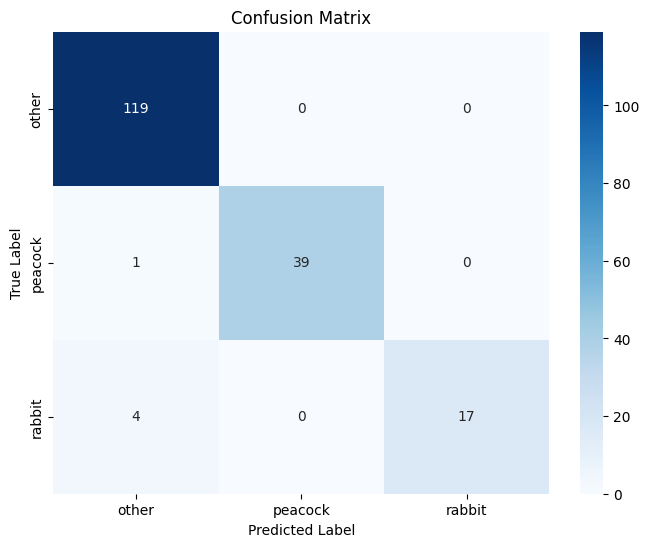

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

ground_truth_data_simplified = {
    'L1000757.JPG': 'other', 'L1000758.JPG': 'other', 'L1000759.JPG': 'other',
    'L1000760.JPG': 'other', 'L1000761.JPG': 'other', 'L1000762.JPG': 'other',
    'L1000764.JPG': 'other', 'L1000766.JPG': 'other', 'L1000767.JPG': 'other',
    'L1000769.JPG': 'other', 'L1000770.JPG': 'other', 'L1000773.JPG': 'other',
    'L1000774.JPG': 'other', 'L1000775.JPG': 'other', 'L1000776.JPG': 'other',
    'L1000777.JPG': 'other', 'L1000778.JPG': 'other', 'L1000781.JPG': 'other',
    'L1000782.JPG': 'other', 'L1000783.JPG': 'other', 'L1000784.JPG': 'other',
    'L1000786.JPG': 'other', 'L1000789.JPG': 'other', 'L1000790.JPG': 'other',
    'L1000794.JPG': 'other', 'L1000795.JPG': 'other', 'L1000796.JPG': 'other',
    'L1000798.JPG': 'other', 'L1000800.JPG': 'other', 'L1000801.JPG': 'other',
    'L1000806.JPG': 'other', 'L1000807.JPG': 'other', 'L1000809.JPG': 'other',
    'L1000811.JPG': 'rabbit', 'L1000813.JPG': 'other', 'L1000814.JPG': 'other',
    'L1000816.JPG': 'other', 'L1000818.JPG': 'other', 'L1000819.JPG': 'other',
    'L1000822.JPG': 'other', 'L1000823.JPG': 'other', 'L1000824.JPG': 'other',
    'L1000825.JPG': 'other', 'L1000829.JPG': 'other', 'L1000830.JPG': 'other',
    'L1000832.JPG': 'other', 'L1000833.JPG': 'other', 'L1000834.JPG': 'other',
    'L1000835.JPG': 'other', 'L1000837.JPG': 'other', 'L1000839.JPG': 'other',
    'L1000840.JPG': 'other', 'L1000841.JPG': 'other', 'L1000842.JPG': 'other',
    'L1000845.JPG': 'other', 'L1000846.JPG': 'other', 'L1000847.JPG': 'other',
    'L1000848.JPG': 'other', 'L1000852.JPG': 'other', 'L1000853.JPG': 'other',
    'L1000856.JPG': 'other', 'L1000857.JPG': 'other', 'L1000858.JPG': 'other',
    'L1000861.JPG': 'other', 'L1000862.JPG': 'other', 'L1000863.JPG': 'other',
    'L1000864.JPG': 'other', 'L1000867.JPG': 'other', 'L1000869.JPG': 'peacock',
    'L1000871.JPG': 'peacock', 'L1000873.JPG': 'peacock', 'L1000874.JPG': 'peacock',
    'L1000877.JPG': 'peacock', 'L1000878.JPG': 'peacock', 'L1000879.JPG': 'other',
    'L1000881.JPG': 'other', 'L1000883.JPG': 'other', 'L1000884.JPG': 'rabbit',
    'L1000886.JPG': 'rabbit', 'L1000887.JPG': 'rabbit', 'L1000891.JPG': 'other',
    'L1000892.JPG': 'other', 'L1000893.JPG': 'other', 'L1000895.JPG': 'other',
    'L1000897.JPG': 'other', 'L1000898.JPG': 'other', 'L1000901.JPG': 'peacock',
    'L1000902.JPG': 'peacock', 'L1000904.JPG': 'peacock', 'L1000905.JPG': 'peacock',
    'L1000906.JPG': 'peacock', 'L1000907.JPG': 'peacock', 'L1000908.JPG': 'peacock',
    'L1000911.JPG': 'other', 'L1000912.JPG': 'other', 'L1000913.JPG': 'other',
    'L1000915.JPG': 'rabbit', 'L1000917.JPG': 'rabbit', # Adjusted from your 'other' prediction
    'L1000918.JPG': 'rabbit', 'L1000919.JPG': 'rabbit',
    'L1000921.JPG': 'other', 'L1000924.JPG': 'other', 'L1000925.JPG': 'other',
    'L1000927.JPG': 'other', 'L1000929.JPG': 'other', 'L1000931.JPG': 'other',
    'L1000933.JPG': 'peacock', 'L1000934.JPG': 'peacock', 'L1000935.JPG': 'peacock',
    'L1000936.JPG': 'peacock', 'L1000937.JPG': 'peacock', 'L1000938.JPG': 'peacock',
    'L1000940.JPG': 'peacock', 'L1000942.JPG': 'other', 'L1000943.JPG': 'other',
    'L1000944.JPG': 'other', 'L1000945.JPG': 'other', 'L1000947.JPG': 'rabbit',
    'L1000948.JPG': 'rabbit', 'L1000949.JPG': 'rabbit', 'L1000955.JPG': 'other',
    'L1000956.JPG': 'other', 'L1000958.JPG': 'other', 'L1000959.JPG': 'other',
    'L1000960.JPG': 'other', 'L1000961.JPG': 'other', 'L1000962.JPG': 'other',
    'L1000966.JPG': 'peacock', 'L1000967.JPG': 'peacock', 'L1000968.JPG': 'peacock',
    'L1000969.JPG': 'peacock', 'L1000970.JPG': 'peacock', # Adjusted from your 'other' prediction
    'L1000973.JPG': 'peacock', 'L1000975.JPG': 'other', 'L1000976.JPG': 'other',
    'L1000978.JPG': 'other', 'L1000980.JPG': 'rabbit', 'L1000982.JPG': 'rabbit',
    'L1000983.JPG': 'rabbit', 'L1000984.JPG': 'rabbit', 'L1000986.JPG': 'other',
    'L1000988.JPG': 'other', 'L1000990.JPG': 'other', 'L1000991.JPG': 'other',
    'L1000994.JPG': 'other', 'L1000995.JPG': 'other', 'L1000996.JPG': 'peacock',
    'L1000997.JPG': 'peacock', 'L1000998.JPG': 'peacock', 'L1000999.JPG': 'peacock',
    'L1010001.JPG': 'peacock', 'L1010002.JPG': 'peacock', 'L1010003.JPG': 'peacock',
    'L1010005.JPG': 'peacock', 'L1010006.JPG': 'other', 'L1010007.JPG': 'other',
    'L1010010.JPG': 'other', 'L1010011.JPG': 'rabbit', 'L1010016.JPG': 'rabbit',
    'L1010018.JPG': 'other', 'L1010020.JPG': 'other', 'L1010021.JPG': 'other',
    'L1010023.JPG': 'other', 'L1010024.JPG': 'other', 'L1010025.JPG': 'other',
    'L1010027.JPG': 'other', 'L1010028.JPG': 'peacock', 'L1010030.JPG': 'peacock',
    'L1010033.JPG': 'peacock', 'L1010034.JPG': 'peacock',
    'L1010036.JPG': 'peacock', # Adjusted from your 'other' prediction
    'L1010037.JPG': 'peacock', 'L1010038.JPG': 'other', 'L1010039.JPG': 'other',
    'L1010040.JPG': 'other', 'L1010042.JPG': 'other', 'L1010043.JPG': 'rabbit',
    'L1010044.JPG': 'rabbit', 'L1010046.JPG': 'rabbit',
    'L1010047.JPG': 'rabbit' # Adjusted from your 'other' prediction
}

# --- Your Predictions Data (from the first CSV) ---
# In a real script, you would load this from your predictions CSV file
# For this example, I'll create a DataFrame from the string you provided.
from io import StringIO

predictions_csv_string = """filename,predicted_label,confidence
L1000825.JPG,other,0.8382310895438186
L1000990.JPG,other,0.8166841972337109
L1000905.JPG,peacock,0.8203732157543377
L1000852.JPG,other,0.9140061680632439
L1000789.JPG,other,0.9185811589705992
L1000869.JPG,peacock,0.7628590296738998
L1010043.JPG,rabbit,0.9220096771055196
L1000773.JPG,other,0.9514466310965398
L1000759.JPG,other,0.9096882173673052
L1000840.JPG,other,0.8951672676904721
L1000857.JPG,other,0.7594684506184027
L1010040.JPG,other,0.9275897448579631
L1000874.JPG,peacock,0.8748117589474578
L1000823.JPG,other,0.865723247596568
L1000781.JPG,other,0.9613427153726931
L1000839.JPG,other,0.85192145229976
L1000897.JPG,other,0.7797203857889959
L1000935.JPG,peacock,0.7721008799508828
L1000786.JPG,other,0.9050612280713013
L1000921.JPG,other,0.780498040387617
L1000800.JPG,other,0.9438889227875341
L1010027.JPG,other,0.7924872434805785
L1000873.JPG,peacock,0.749491750834631
L1000830.JPG,other,0.9309765864158877
L1000893.JPG,other,0.8167505117615533
L1000961.JPG,other,0.8132791344117642
L1010006.JPG,other,0.9660552824068468
L1000994.JPG,other,0.7990950797517217
L1000856.JPG,other,0.7893611873686106
L1000912.JPG,other,0.9521472841739879
L1010039.JPG,other,0.9244108470393652
L1000913.JPG,other,0.9627748937582741
L1010011.JPG,rabbit,0.7078882466827414
L1010024.JPG,other,0.8083851605391112
L1010044.JPG,rabbit,0.9263460894017604
L1000982.JPG,rabbit,0.7801688697851432
L1000782.JPG,other,0.9352620335223947
L1010021.JPG,other,0.8793687811038641
L1000978.JPG,other,0.9508630822241335
L1010025.JPG,other,0.8677150473589654
L1000960.JPG,other,0.7760178177078831
L1010034.JPG,peacock,0.6973079838818892
L1000925.JPG,other,0.661908706772091
L1000933.JPG,peacock,0.8975351812066666
L1000945.JPG,other,0.9586709112437687
L1000929.JPG,other,0.8394803278230011
L1000997.JPG,peacock,0.8701695207429653
L1000947.JPG,rabbit,0.8690310192223619
L1010038.JPG,other,0.9407153513512911
L1000864.JPG,other,0.8411253541687987
L1000967.JPG,peacock,0.7995662376471818
L1010002.JPG,peacock,0.7798328075017956
L1000809.JPG,other,0.7393302106030093
L1000796.JPG,other,0.9382758522881677
L1000777.JPG,other,0.9482669364021639
L1010037.JPG,peacock,0.716888386074355
L1000898.JPG,other,0.864258799997601
L1000822.JPG,other,0.8604209067842324
L1000911.JPG,other,0.9637322139065796
L1000764.JPG,other,0.8981318879318996
L1000783.JPG,other,0.9366626963810389
L1000867.JPG,other,0.8295559380139907
L1000766.JPG,other,0.9411429408209788
L1000956.JPG,other,0.7694966676326721
L1000884.JPG,other,0.8592284818254937
L1000841.JPG,other,0.8562677465851415
L1000958.JPG,other,0.815878096188602
L1000931.JPG,other,0.7569345026447135
L1010020.JPG,other,0.7746684503995268
L1000858.JPG,other,0.724368202352685
L1000949.JPG,rabbit,0.8404064050410102
L1010033.JPG,peacock,0.7199339240930421
L1000936.JPG,peacock,0.8909468512886523
L1000906.JPG,peacock,0.8296867950179884
L1000986.JPG,other,0.8405866901136709
L1000975.JPG,other,0.9653439680995515
L1000824.JPG,other,0.8873602021284885
L1010028.JPG,peacock,0.8433376191224223
L1000940.JPG,peacock,0.8457729036076213
L1000846.JPG,other,0.8899168996060383
L1010003.JPG,peacock,0.873192303308312
L1000832.JPG,other,0.8749217629229237
L1000908.JPG,peacock,0.8383451160116856
L1000757.JPG,other,0.905175590902517
L1000943.JPG,other,0.9683226624092178
L1000758.JPG,other,0.9038081367132216
L1010042.JPG,other,0.9530037647852578
L1000816.JPG,other,0.8149882718461328
L1000834.JPG,other,0.8787883442287917
L1000798.JPG,other,0.9478732554055618
L1000879.JPG,other,0.9687509552296862
L1000861.JPG,other,0.7794583736023878
L1000845.JPG,other,0.9292743567979589
L1000760.JPG,other,0.9289777425728328
L1000976.JPG,other,0.9529053474487672
L1000984.JPG,rabbit,0.9195016299842403
L1010046.JPG,rabbit,0.8985258971770954
L1000907.JPG,peacock,0.8161724258560378
L1000801.JPG,other,0.935169856189822
L1000934.JPG,peacock,0.9071387833076117
L1000842.JPG,other,0.8631872366624125
L1000794.JPG,other,0.9085565317135931
L1000998.JPG,peacock,0.8163615853769898
L1000895.JPG,other,0.8700285601695696
L1000891.JPG,other,0.7935133480593543
L1000968.JPG,peacock,0.7845845103656112
L1000881.JPG,other,0.973508574235681
L1010023.JPG,other,0.6857249126693606
L1000983.JPG,rabbit,0.8433194279758922
L1000762.JPG,other,0.9317574658370716
L1000973.JPG,peacock,0.8314253532929374
L1000761.JPG,other,0.9149538222288482
L1000775.JPG,other,0.9519021972669279
L1000883.JPG,other,0.9678442636625324
L1000848.JPG,other,0.8940789968887615
L1000807.JPG,other,0.9063041372036601
L1000970.JPG,peacock,0.7099691232355166 
L1010036.JPG,other,0.7335787873897639
L1000835.JPG,other,0.9245957977718501
L1000847.JPG,other,0.8948763575757732
L1000948.JPG,rabbit,0.8918165268599813
L1000902.JPG,peacock,0.8872057610497626
L1000878.JPG,peacock,0.8267015547186656
L1000955.JPG,other,0.7883111228778173
L1000938.JPG,peacock,0.7909779330598665
L1010018.JPG,other,0.8204542663016341
L1000904.JPG,peacock,0.8779794447352725
L1000814.JPG,other,0.8945549308510558
L1000769.JPG,other,0.9410646260655009
L1000877.JPG,peacock,0.8782451607737489
L1000806.JPG,other,0.9079316171779567
L1000833.JPG,other,0.7989497642208626
L1000784.JPG,other,0.923394169805178
L1000790.JPG,other,0.9602950154287969
L1000892.JPG,other,0.766296392755294
L1000959.JPG,other,0.795686692732337
L1000991.JPG,other,0.757272386642753
L1000829.JPG,other,0.8276971106023037
L1010047.JPG,other,0.862038611148686
L1000917.JPG,other,0.8489072802327678
L1000962.JPG,other,0.8319988010360675
L1000969.JPG,peacock,0.8230885233983066
L1000927.JPG,other,0.8075835067214155
L1000942.JPG,other,0.9665209779572969
L1000966.JPG,peacock,0.7820535609154449
L1000863.JPG,other,0.7793074682582418
L1000813.JPG,other,0.8695995697427763
L1000811.JPG,other,0.8050965164595952
L1000996.JPG,peacock,0.8711534439690333
L1000944.JPG,other,0.9690159296224132
L1000770.JPG,other,0.9600112368380198
L1000995.JPG,other,0.7343855471446782
L1000767.JPG,other,0.9464872723687616
L1000795.JPG,other,0.9595657079466996
L1010005.JPG,peacock,0.8269656669576377
L1010016.JPG,rabbit,0.7949896011612515
L1000901.JPG,peacock,0.8785255576883166
L1000919.JPG,rabbit,0.8669298797964483
L1000937.JPG,peacock,0.8596033904623326
L1000774.JPG,other,0.9551727372013271
L1010001.JPG,peacock,0.8408540860588353
L1010010.JPG,other,0.9720826655978234
L1000853.JPG,other,0.9210808145132481
L1000924.JPG,other,0.6981240439818492
L1000886.JPG,rabbit,0.9021271192505737
L1000980.JPG,rabbit,0.9203227959325891
L1010030.JPG,peacock,0.7899766062981637
L1000988.JPG,other,0.8230211263777454
L1000918.JPG,rabbit,0.8668672432528709
L1000818.JPG,other,0.8858044038797018
L1000915.JPG,rabbit,0.9008090396574845
L1000776.JPG,other,0.935108883440539
L1000778.JPG,other,0.9617225406282042
L1010007.JPG,other,0.9639524222087686
L1000887.JPG,rabbit,0.9151877890893063
L1000862.JPG,other,0.7202783976031549
L1000871.JPG,peacock,0.7912680305992593
L1000999.JPG,peacock,0.8237940439612877
L1000819.JPG,other,0.7928243214936036
L1000837.JPG,other,0.8331103527205901"""

predictions_df = pd.read_csv(StringIO(predictions_csv_string))




# --- Calculate Accuracy ---
y_true = []
y_pred = []
labels = sorted(list(set(ground_truth_data_simplified.values()) | set(predictions_df['predicted_label'].unique())))


for idx, row in predictions_df.iterrows():
    filename = row['filename']
    predicted = row['predicted_label']
    
    true_label = ground_truth_data_simplified.get(filename)
    
    if true_label is not None:
        y_true.append(true_label)
        y_pred.append(predicted)
    else:
        print(f"Warning: No ground truth found for predicted file '{filename}'. Skipping for accuracy calculation.")

if not y_true:
    print("No matching ground truth data found for the predicted files. Cannot calculate accuracy.")
else:
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n--- Overall Accuracy ---")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    
    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print(cm)
    
    # Plotting the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show(block=True) # Make sure this is the last plot or manage plot windows

#### Model Loading + Test (one image at a time)



--- Example: Predicting on a New Test Image ---
Test: Model and scaler loaded successfully.
Test: Processing test image: data/test/L1000869.JPG
Test: Found 6 segments in the test image.
  Test Segment 0: Predicted raw label = 9
  Test Segment 1: Predicted raw label = 5
  Test Segment 2: Predicted raw label = 5
  Test Segment 3: Predicted raw label = 6
  Test Segment 4: Predicted raw label = 8
  Test Segment 5: Predicted raw label = 6


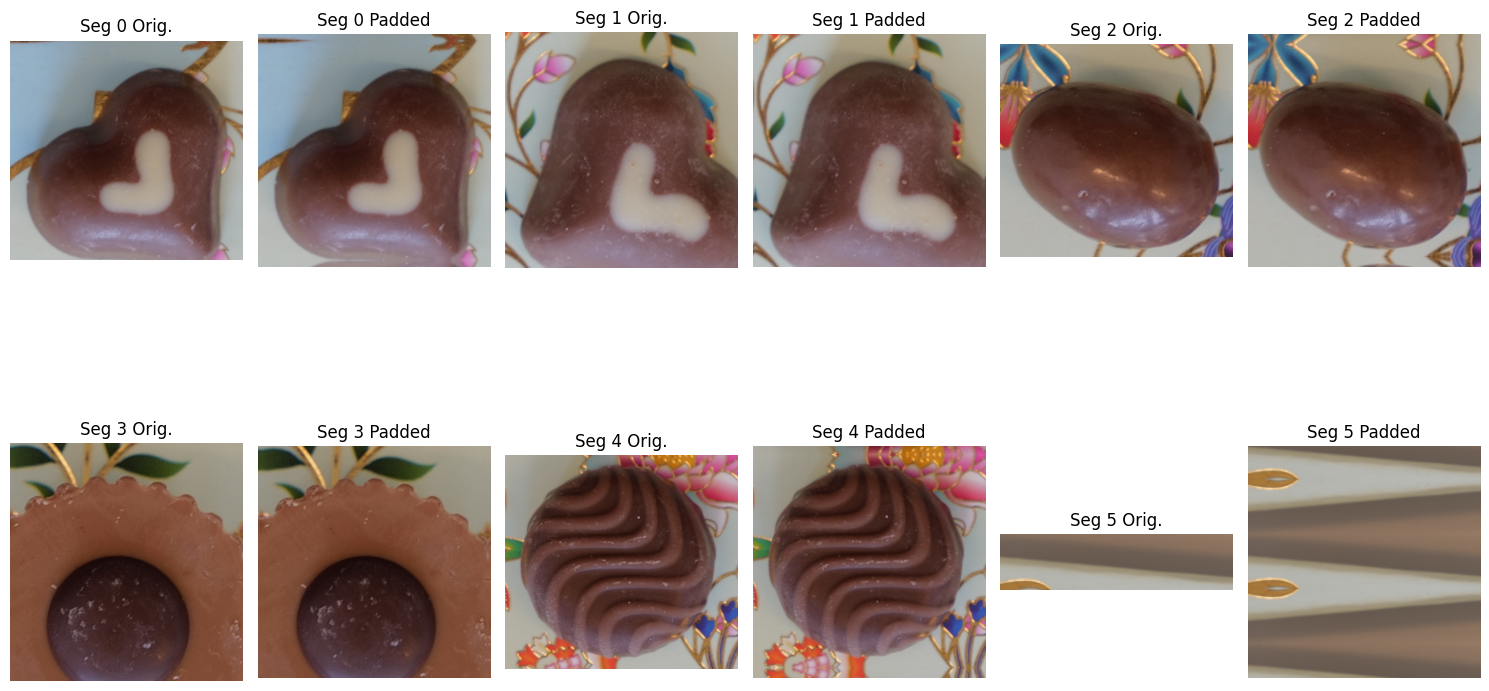


Predicted labels for successfully processed segments in test image:


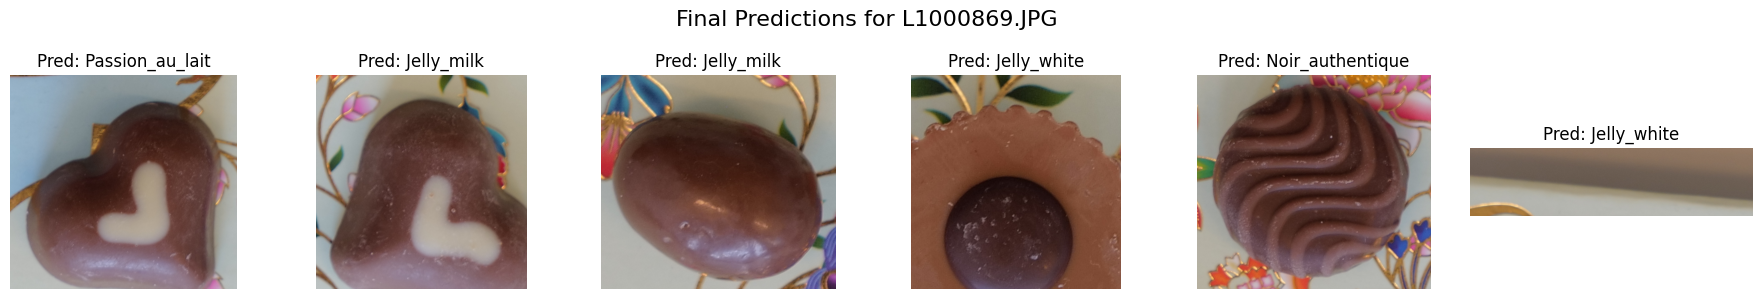

In [22]:
import joblib
print("\n\n--- Example: Predicting on a New Test Image ---")
try:
    clf_loaded = joblib.load("chocolate_classifier_model_tuned.joblib")
    scaler_loaded = joblib.load("chocolate_feature_scaler_tuned.joblib")
    print("Test: Model and scaler loaded successfully.")
except FileNotFoundError:
    print("Test: Model or scaler file not found. Cannot run test prediction example.")
    clf_loaded, scaler_loaded = None, None # Ensure they are None if not loaded
except Exception as e:
    print(f"Test: Error loading model/scaler: {e}")
    clf_loaded, scaler_loaded = None, None

if clf_loaded and scaler_loaded:
    df = pd.read_csv('test_predictions_simplified.csv')
    test_image_path = "data/test/L1000869.JPG" 
    print(f"Test: Processing test image: {test_image_path}")
    filename = test_image_path.split('/')[-1]

    row = df[df['filename'] == filename]

    if row.empty:
        print(f"Filename '{filename}' not found in CSV.")
        test_segments = []
    else:
        label = row['predicted_label'].values[0]

        if label == "peacock":
            test_segments = extract_chocolates_with_peacock_mask(test_image_path)
            print(f"Test: Found {len(test_segments)} segments in the test image.")
        elif label == "rabbit":
            # test_segments = extract_chocolates_with_rabbit_mask(test_image_path)
            # print(f"Test: Found {len(test_segments)} segments in the test image.")
            test_segments = []  # Placeholder if you haven't implemented it
            print("Rabbit background - segmentation function not active.")
        else:
            test_segments = extract_chocolate_segments(test_image_path)
            print(f"Test: Found {len(test_segments)} segments in the test image.")

    
    if test_segments:
        predicted_labels_on_test = []
        valid_test_segments_for_viz = []
        
        plt.figure(figsize=(15, 5 * math.ceil(len(test_segments) / 3))) # Adjust figure size
        plot_idx = 1

        for i, seg_img in enumerate(test_segments):
            if seg_img is None or seg_img.shape[0] == 0 or seg_img.shape[1] == 0:
                print(f"  Test Segment {i} is invalid, skipping.")
                continue
            
            # --- Visualize original and resized/padded for debugging test segments ---
            plt.subplot(math.ceil(len(test_segments) / 3), 6, plot_idx) # 2 plots per segment in a row
            plt.imshow(cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Seg {i} Orig.")
            plt.axis('off')
            plot_idx +=1
            
            try:
                resized_padded_seg_for_viz = resize_and_pad(seg_img, RESIZE_DIM)
                plt.subplot(math.ceil(len(test_segments) / 3), 6, plot_idx)
                plt.imshow(cv2.cvtColor(resized_padded_seg_for_viz, cv2.COLOR_BGR2RGB))
                plt.title(f"Seg {i} Padded")
                plt.axis('off')
                plot_idx +=1
            except Exception as e_viz:
                print(f"  Error visualizing resized/padded for test segment {i}: {e_viz}")
                plot_idx +=1 # Still increment plot_idx to maintain layout if one plot fails

            # --- Feature Extraction and Prediction ---
            try:
                current_features_raw = extract_all_features(seg_img)
                current_features_scaled = scaler_loaded.transform([current_features_raw])
                prediction = clf_loaded.predict(current_features_scaled)
                
                predicted_labels_on_test.append(prediction[0])
                valid_test_segments_for_viz.append(seg_img) # Store original for final viz
                print(f"  Test Segment {i}: Predicted raw label = {prediction[0]}")
            except Exception as e_pred:
                print(f"  Error processing/predicting for test segment {i}: {e_pred}. Skipping.")
                if plot_idx % 2 != 1 : # If we are on the "padded" slot, ensure next segment starts fresh
                        plot_idx +=1 # This logic might need refinement if errors are frequent


        if plot_idx > 1: # Only show plot if there was something to plot
            plt.tight_layout()
            plt.show()

        # --- Final Summary Visualization (similar to before) ---
        if valid_test_segments_for_viz:
            label_mapping = {
                0: 'Amandina', 1: 'Arabia', 2: 'Comtesse', 3: 'Creme_brulee', 4: 'Jelly_black',
                5: 'Jelly_milk', 6: 'Jelly_white', 7: 'Noblesse', 8: 'Noir_authentique',
                9: 'Passion_au_lait', 10: 'Stracciatella', 11: 'Tentation_noir', 12: 'Triangolo'
            }
            human_readable_predictions = [label_mapping.get(label, f"Unknown_{label}") for label in predicted_labels_on_test]
            # ... (rest of your final summary visualization code) ... 
            print("\nPredicted labels for successfully processed segments in test image:")
            # ... (print loop) ...
            # ... (matplotlib figure for final predictions) ...
            num_segments_viz = len(valid_test_segments_for_viz)
            cols_viz = min(6, num_segments_viz)
            rows_viz = math.ceil(num_segments_viz / cols_viz)
            if rows_viz > 0 and cols_viz > 0 : # Ensure we can create subplot
                plt.figure(figsize=(cols_viz * 3, rows_viz * 3))
                plt.suptitle(f"Final Predictions for {os.path.basename(test_image_path)}", fontsize=16)
                for i, (seg_v, h_label_v) in enumerate(zip(valid_test_segments_for_viz, human_readable_predictions)):
                    plt.subplot(rows_viz, cols_viz, i + 1)
                    plt.imshow(cv2.cvtColor(seg_v, cv2.COLOR_BGR2RGB)) # Show original segment
                    plt.title(f"Pred: {h_label_v}")
                    plt.axis('off')
                plt.tight_layout(rect=[0, 0, 1, 0.96])
                plt.show()
    else:
        print("Test: No valid segments extracted from the test image.")
else:
    print("Test: Model and/or scaler not loaded. Skipping test prediction example.")

#### CSV Submission Creation 

Note: fix the column titles at the end in the CSV lol

In [ ]:
import os
import cv2
import math
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load model and scaler
clf_loaded = joblib.load("chocolate_classifier_model_tuned.joblib")
scaler_loaded = joblib.load("chocolate_feature_scaler_tuned.joblib")

# Label mapping
label_mapping = {
    0: 'Amandina', 1: 'Arabia', 2: 'Comtesse', 3: 'Creme_brulee', 4: 'Jelly_black',
    5: 'Jelly_milk', 6: 'Jelly_white', 7: 'Noblesse', 8: 'Noir_authentique',
    9: 'Passion_au_lait', 10: 'Stracciatella', 11: 'Tentation_noir', 12: 'Triangolo'
}
ordered_labels = ['Jelly_white', 'Jelly_milk', 'Jelly_black', 'Amandina', 'Creme_brulee', 
                  'Triangolo', 'Tentation_noir', 'Comtesse', 'Noblesse', 
                  'Noir_authentique', 'Passion_au_lait', 'Arabia', 'Stracciatella']

# Final prediction storage
results = []
all_valid_segments = []
all_predicted_human_labels = []

# Process each test image
for fname in os.listdir("data/test"):
    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join("data/test", fname)
    segments = extract_chocolate_segments(image_path)
    
    predicted_labels = []
    valid_segments = []

    for seg in segments:
        if seg is None or seg.shape[0] == 0 or seg.shape[1] == 0:
            continue

        try:
            features = extract_all_features(seg)
            scaled_features = scaler_loaded.transform([features])
            pred = clf_loaded.predict(scaled_features)[0]
            predicted_labels.append(pred)
            valid_segments.append(seg)
        except:
            continue

    # Count chocolate types
    label_counts = Counter(predicted_labels)
    result_row = {
        "id": os.path.splitext(fname)[0].replace("L", "")  # 'L1000781.JPG' → '1000781'
    }
    for label_name in ordered_labels:
        idx = list(label_mapping.keys())[list(label_mapping.values()).index(label_name)]
        result_row[label_name] = label_counts.get(idx, 0)
    results.append(result_row)

    # Save for visualization
    all_valid_segments.extend(valid_segments)
    all_predicted_human_labels.extend(
        [label_mapping.get(lbl, f"Unknown_{lbl}") for lbl in predicted_labels]
    )

# Save to CSV
df_results = pd.DataFrame(results)
df_results.to_csv("chocolate_test_predictions_BG.csv", index=False)

# Final visualization
# if all_valid_segments:
#     num = len(all_valid_segments)
#     cols = min(6, num)
#     rows = math.ceil(num / cols)
#     plt.figure(figsize=(cols * 3, rows * 3))
#     plt.suptitle("Final Predictions for Test Chocolates", fontsize=16)

#     for i, (img, label) in enumerate(zip(all_valid_segments, all_predicted_human_labels)):
#         plt.subplot(rows, cols, i + 1)
#         plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#         plt.title(f"Pred: {label}")
#         plt.axis('off')

#     plt.tight_layout(rect=[0, 0, 1, 0.96])
#     plt.show()


KeyboardInterrupt: 

In [ ]:
# BGGGGG
import os
import cv2
import math
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load model and scaler
clf_loaded = joblib.load("chocolate_classifier_model_tuned.joblib")
scaler_loaded = joblib.load("chocolate_feature_scaler_tuned.joblib")

# Label mapping
label_mapping = {
    0: 'Amandina', 1: 'Arabia', 2: 'Comtesse', 3: 'Creme_brulee', 4: 'Jelly_black',
    5: 'Jelly_milk', 6: 'Jelly_white', 7: 'Noblesse', 8: 'Noir_authentique',
    9: 'Passion_au_lait', 10: 'Stracciatella', 11: 'Tentation_noir', 12: 'Triangolo'
}
ordered_labels = ['Jelly_white', 'Jelly_milk', 'Jelly_black', 'Amandina', 'Creme_brulee', 
                  'Triangolo', 'Tentation_noir', 'Comtesse', 'Noblesse', 
                  'Noir_authentique', 'Passion_au_lait', 'Arabia', 'Stracciatella']

# Final prediction storage
results = []
all_valid_segments = []
all_predicted_human_labels = []

# Process each test image
for filename in os.listdir("data/test"):
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    image_path = os.path.join("data/test", filename)

    df = pd.read_csv('test_predictions_simplified.csv')

    row = df[df['filename'] == filename]

    if row.empty:
        print(f"Filename '{filename}' not found in CSV.")
        test_segments = []
    else:
        label = row['predicted_label'].values[0]

        if label == "peacock":
            test_segments = extract_chocolates_with_peacock_mask(test_image_path)
            # print(f"Test: Found {len(test_segments)} segments in the test image.")
        elif label == "rabbit":
            test_segments = extract_chocolates_with_rabbit_mask(test_image_path)
            # print(f"Test: Found {len(test_segments)} segments in the test image.")
        else:
            test_segments = extract_chocolate_segments(test_image_path)
            # print(f"Test: Found {len(test_segments)} segments in the test image.")
    
    predicted_labels = []
    valid_segments = []

    for seg in test_segments:
        if seg is None or seg.shape[0] == 0 or seg.shape[1] == 0:
            continue

        try:
            features = extract_all_features(seg)
            scaled_features = scaler_loaded.transform([features])
            pred = clf_loaded.predict(scaled_features)[0]
            predicted_labels.append(pred)
            valid_segments.append(seg)
        except:
            continue

    # Count chocolate types
    label_counts = Counter(predicted_labels)
    result_row = {
        "id": os.path.splitext(filename)[0].replace("L", "")  
    }
    for label_name in ordered_labels:
        idx = list(label_mapping.keys())[list(label_mapping.values()).index(label_name)]
        result_row[label_name] = label_counts.get(idx, 0)
    results.append(result_row)

    # Save for visualization
    all_valid_segments.extend(valid_segments)
    all_predicted_human_labels.extend(
        [label_mapping.get(lbl, f"Unknown_{lbl}") for lbl in predicted_labels]
    )

# Save to CSV
df_results = pd.DataFrame(results)
df_results.to_csv("chocolate_test_predictions_BG.csv", index=False)



#### CSV Comparisons

Again, COLUMNS!

In [25]:
import pandas as pd

def compare_csv_with_accuracy(file1, file2):
    df1 = pd.read_csv(file1)
    df2 = pd.read_csv(file2)

    # Sort rows and reset index to ignore order differences
    df1_sorted = df1.sort_values(by=df1.columns.tolist()).reset_index(drop=True)
    df2_sorted = df2.sort_values(by=df2.columns.tolist()).reset_index(drop=True)

    # Check if shapes differ, handle smaller common shape
    min_rows = min(df1_sorted.shape[0], df2_sorted.shape[0])
    min_cols = min(df1_sorted.shape[1], df2_sorted.shape[1])

    # Trim dataframes to common shape for comparison
    df1_trim = df1_sorted.iloc[:min_rows, :min_cols]
    df2_trim = df2_sorted.iloc[:min_rows, :min_cols]

    # Compare element-wise equality
    comparison = df1_trim.eq(df2_trim)

    total_cells = min_rows * min_cols
    matching_cells = comparison.sum().sum()

    accuracy = matching_cells / total_cells

    print(f"Shape file1: {df1_sorted.shape}, Shape file2: {df2_sorted.shape}")
    print(f"Compared {min_rows} rows and {min_cols} columns")
    print(f"Matching cells: {matching_cells} / {total_cells}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Optionally print mismatched rows
    if accuracy < 1.0:
        print("\nMismatched rows and their differences:")
        for i in range(min_rows):
            if not comparison.iloc[i].all():
                print(f"\nRow {i}:")
                row1 = df1_trim.iloc[i]
                row2 = df2_trim.iloc[i]
                diffs = {col: (row1[col], row2[col]) for col in df1_trim.columns if row1[col] != row2[col]}
                print(diffs)
    else:
        print("Files have identical rows and values in the overlapping area!")

if __name__ == "__main__":
    file1 = 'chocolate_test_predictions_BG.csv'
    file2 = 'chocolate_test_predictions_BG_no_rabbit.csv'
    compare_csv_with_accuracy(file1, file2)


Shape file1: (180, 14), Shape file2: (180, 14)
Compared 180 rows and 14 columns
Matching cells: 2401 / 2520
Accuracy: 0.9528 (95.28%)

Mismatched rows and their differences:

Row 78:
{'Jelly White': (np.int64(0), np.int64(2)), 'Jelly Milk': (np.int64(1), np.int64(0)), 'Jelly Black': (np.int64(0), np.int64(1)), 'Triangolo': (np.int64(0), np.int64(1)), 'Tentation noir': (np.int64(1), np.int64(0)), 'Noblesse': (np.int64(1), np.int64(0)), 'Passion au lait': (np.int64(0), np.int64(2))}

Row 79:
{'Jelly White': (np.int64(0), np.int64(2)), 'Jelly Milk': (np.int64(1), np.int64(0)), 'Jelly Black': (np.int64(0), np.int64(1)), 'Triangolo': (np.int64(0), np.int64(1)), 'Tentation noir': (np.int64(1), np.int64(0)), 'Noblesse': (np.int64(1), np.int64(0)), 'Passion au lait': (np.int64(0), np.int64(2))}

Row 96:
{'Jelly White': (np.int64(0), np.int64(2)), 'Jelly Milk': (np.int64(1), np.int64(0)), 'Jelly Black': (np.int64(0), np.int64(1)), 'Triangolo': (np.int64(0), np.int64(1)), 'Tentation noir': (np.i